In [7]:
# Tratamiento de datos
# -----------------------------------------------------------------------
import pandas as pd
import numpy as np

# Visualización
# ------------------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluar linealidad de las relaciones entre las variables
# ------------------------------------------------------------------------------
from scipy.stats import shapiro, kstest

# Gestión de los warnings
# -----------------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")
#-----------------------------------------------------------------------
pd.set_option('display.max_columns', None) # para poder visualizar todas las columnas de los DataFrames


In [8]:
# traer documento df, lo pongo sin index col por que mi index ya es loyalty number
df_final_copia=pd.read_csv('Files/customer_loyalty_cleaned.csv',index_col=0) 

In [9]:
df_final_copia.head(2)

,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Status,Cancellation Year,Cancellation Month,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
Loyalty Number,,,,,,,,,,,,,,,,,,,,,,,,
480934,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,Activo,NaN,NaN,2017,1,0,0,0,0,0.0,0,0
480934,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,Activo,NaN,NaN,2017,2,3,0,3,2823,282.0,0,0


## FASE 3 VISUALIZACION

. ¿Cómo se distribuye la cantidad de vuelos reservados por mes durante el año?. ¿Cómo se distribuye la cantidad de vuelos reservados por mes durante el año?
. ¿Existe una relación entre la distancia de los vuelos y los puntos acumulados por los cliente?
. ¿Cuál es la distribución de los clientes por provincia o estado?
. ¿Cómo se compara el salario promedio entre los diferentes niveles educativos de los clientes?
. ¿Cuál es la proporción de clientes con diferentes tipos de tarjetas de fidelidad?
. ¿Cómo se distribuyen los clientes según su estado civil y género?


¿Cómo se distribuye la cantidad de vuelos reservados por mes durante el año?.

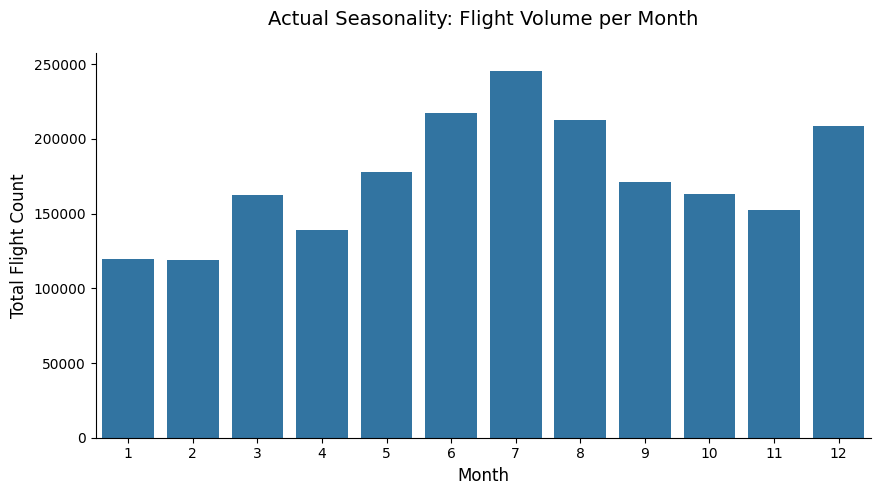

In [70]:

vuelos_por_mes = df_final_copia.groupby('Month')['Total Flights'].sum().reset_index()# se lee suma de total flights por meses


plt.figure(figsize=(10, 5))
ax = sns.barplot(data=vuelos_por_mes, x='Month', y='Total Flights')


plt.title('Actual Seasonality: Flight Volume per Month', fontsize=14, pad=20)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Flight Count', fontsize=12)

plt.gca().spines['right'].set_visible(False) # elimina la linea de la derecha del recuadro dando un aspecto mas moderno
plt.gca().spines['top'].set_visible(False) # elimina la linea de arriba del recuadro dando un aspecto mas moderno


plt.show()

In [11]:
# observamos que los meses que mas se vende es julio seguido de junio ,agosto y diciembre

¿Cuál es la distribución de los clientes por provincia o estado?

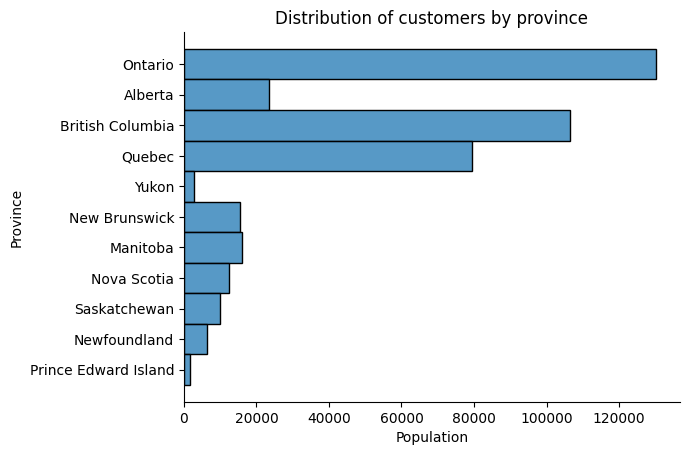

In [69]:
sns.histplot(data=df_final_copia,
             y='Province',
             bins=11
         
            
)
plt.xlabel('Population')
plt.ylabel('Province')
plt.title ('Distribution of customers by province')
plt.gca().spines['right'].set_visible(False)# elimina la linea de la derecha hace que sea mas moderno
plt.gca().spines['top'].set_visible(False)

In [ ]:
#vemos que la claramente que la mayoria de los clientes son de Ontario, British Columbia o Quebec, en ese orden
#amplia mayoria de estas 3  cuidades 

#. ¿Cómo se compara el salario promedio entre los diferentes niveles educativos de los clientes?


In [37]:
salario_promedio_educacion = round(df_final_copia.groupby('Education')['Salary'].mean(),2)
print(salario_promedio_educacion)

Education
Bachelor                 72666.32
College                  73479.00
Doctor                  178403.68
High School or Below     61161.57
Master                  103734.52
Name: Salary, dtype: float64


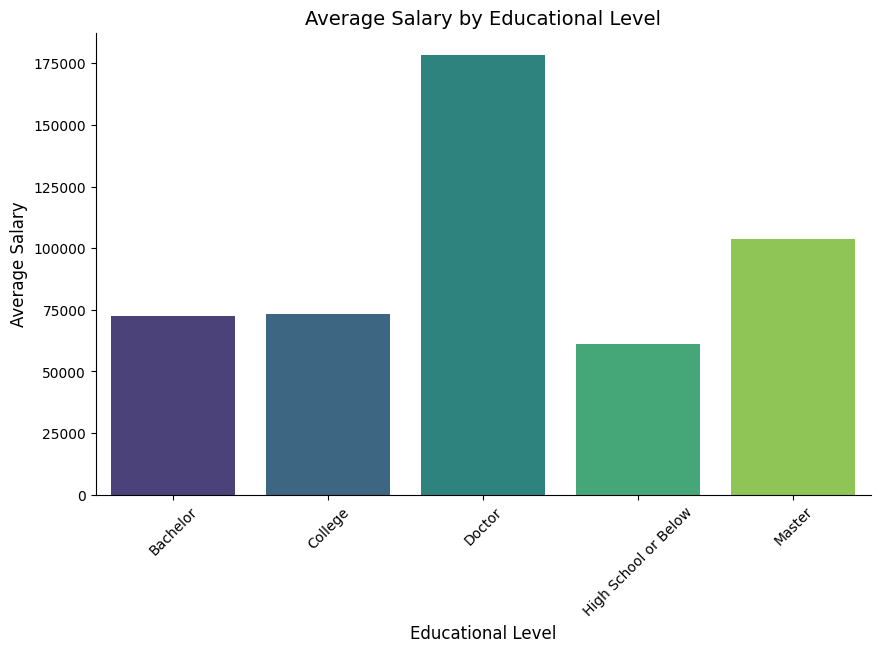

In [68]:

salario_promedio_educacion = df_final_copia.groupby('Education')['Salary'].mean().reset_index()


plt.figure(figsize=(10, 6))
sns.barplot(data=salario_promedio_educacion, x='Education', y='Salary', palette='viridis')

plt.title('Average Salary by Educational Level', fontsize=14)
plt.xlabel('Educational Level', fontsize=12)
plt.ylabel('Average Salary', fontsize=12)
plt.xticks(rotation=45)


plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)

plt.show()

In [ ]:
#vemos que las personas que mas cobran son las que tienen la educacion mas alta

. ¿Cuál es la proporción de clientes con diferentes tipos de tarjetas de fidelidad?

In [ ]:
#asi saco la proporcion en codigo

Star=round(((df_final_copia['Loyalty Card'] == 'Star').sum() / df_final_copia.shape[0]) * 100, 2)
Aurora=round(((df_final_copia['Loyalty Card'] == 'Aurora').sum() / df_final_copia.shape[0]) * 100, 2)
Nova=round(((df_final_copia['Loyalty Card'] == 'Nova').sum() / df_final_copia.shape[0]) * 100, 2)

print(f'Star: {Star}%%\nNova: {Nova}%\nAurora: {Aurora}' )

Star: 45.51%%
Nova: 33.9%
Aurora: 20.59


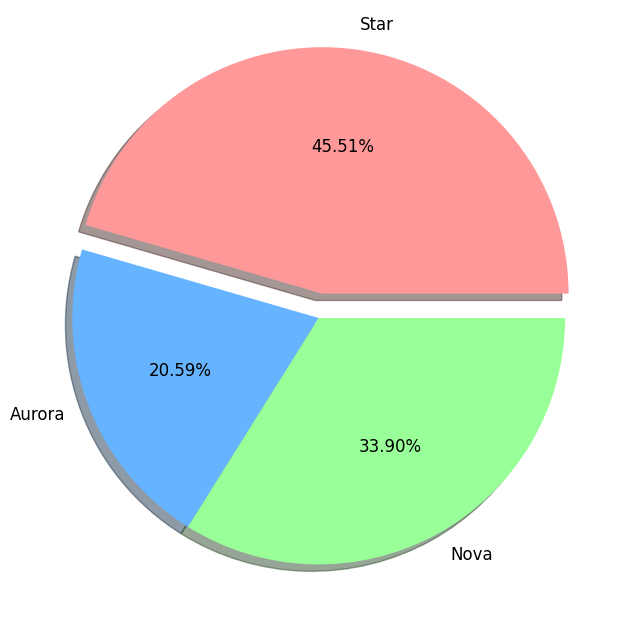

In [67]:
# Definimos los datos (asegúrate de que Star, Aurora y Nova existan arriba)
valores = [Star, Aurora, Nova]
etiquetas = ['Star', 'Aurora', 'Nova']
colores = ['#ff9999','#66b3ff','#99ff99'] 
desfase = (0.1, 0, 0) 

plt.figure(figsize=(8, 8))

plt.pie(
    valores, 
    labels=etiquetas, 
    autopct='%1.2f%%', #primer uno despues % es ancho total el campo , el 2 despues de punto, cuantos digitos despues del decimal
    textprops={'fontsize': 12},# tamaño del a letra
    colors=colores,# poner diferentes paletas de colores
    explode=desfase,   # hace ese efecto sacado 
    shadow=True        
)

plt.title('', fontsize=14, pad=20)
plt.show('Customer Distribution by Loyalty Card')

. ¿Cómo se distribuyen los clientes según su estado civil y género?


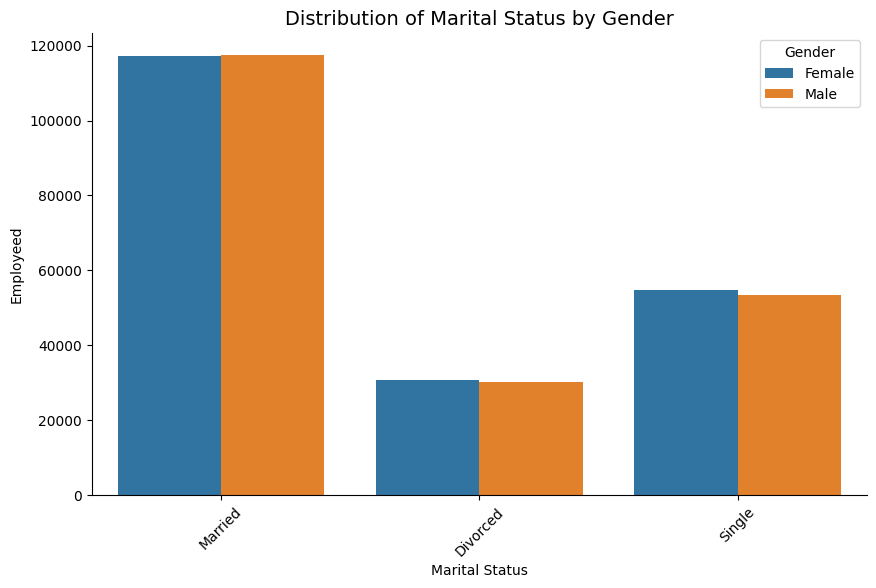

In [66]:
# hacemos countplot para comparar 2 categoricas

plt.figure(figsize=(10, 6))


sns.countplot(
    data=df_final_copia, 
    x='Marital Status', 
    hue='Gender', 
   
)

plt.title('Distribution of Marital Status by Gender', fontsize=14)
plt.xlabel('Marital Status')
plt.ylabel('Employeed')
plt.xticks(rotation=45)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.show()

In [ ]:
#si recordamos los datos ya vimos que estaban parejos los generos, nos viene a decir que no hay diferencia de genero
# cabe destacar que el genero que mas personas tiene es ampliamante Married 